<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### Install the required libraries and import them


In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


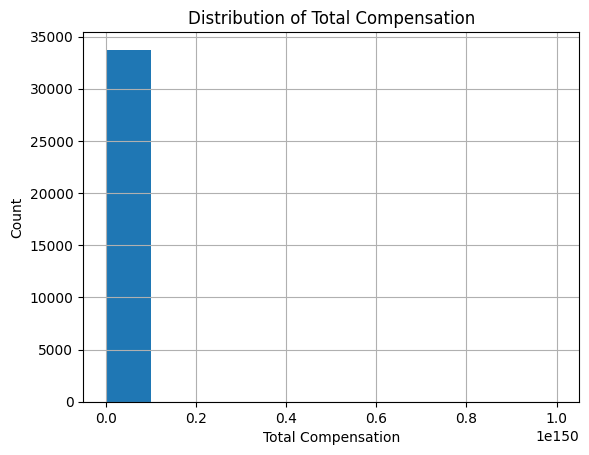

In [9]:
# Part 1: Get the data from the database
QUERY = """
SELECT CompTotal FROM main
WHERE CompTotal IS NOT NULL
"""
df1 = pd.read_sql_query(QUERY, conn)

# Part 2: Draw the histogram
df1['CompTotal'].hist()
plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Count")
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


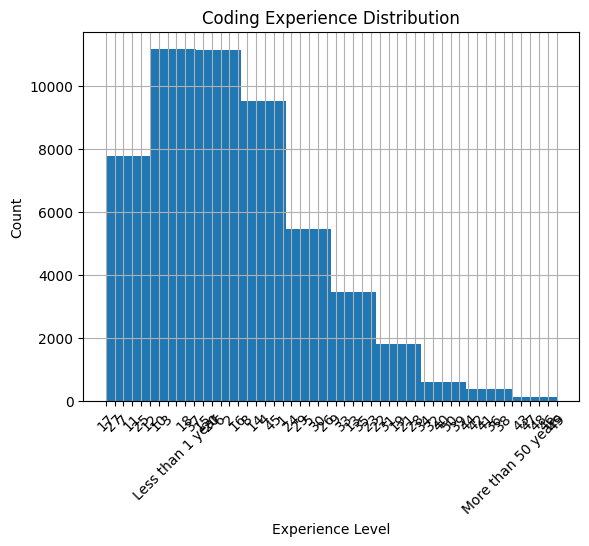

In [12]:
QUERY = """
SELECT YearsCodePro FROM main
WHERE YearsCodePro IS NOT NULL
"""
df2 = pd.read_sql_query(QUERY, conn)

df2['YearsCodePro'].hist()
plt.title ("Coding Experience Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


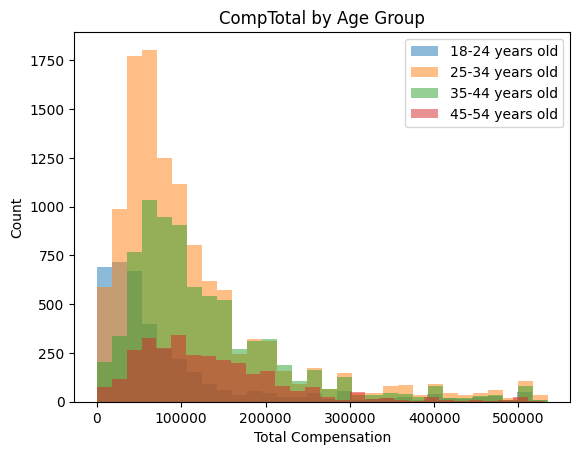

In [14]:
# Part 1: Get the data from the database
QUERY = """
SELECT Age, CompTotal FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL
"""
df3 = pd.read_sql_query(QUERY, conn)

# Remove outliers using IQR method (you learned this in Lab 15!)
Q1 = df3['CompTotal'].quantile(0.25)
Q3 = df3['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df3 = df3[(df3['CompTotal'] >= lower) & (df3['CompTotal'] <= upper)]


# Part 2: Pick a few age groups to compare (not all — too messy)
age_groups = ['18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old']

# Part 3: Draw one histogram for each age group on the same picture
for age in age_groups:
    group_data = df3[df3['Age'] == age]['CompTotal']
    plt.hist(group_data, bins=30, alpha=0.5, label=age)

plt.title("CompTotal by Age Group")
plt.xlabel("Total Compensation")
plt.ylabel("Count")
plt.legend()
plt.show()


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


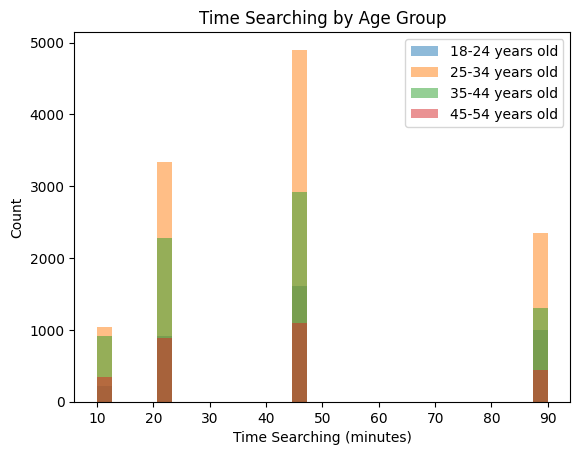

In [16]:
# Part 1: Get the data from the database
QUERY = """
SELECT TimeSearching, Age FROM main
WHERE TimeSearching IS NOT NULL 
AND Age IS NOT NULL
"""
df4 = pd.read_sql_query(QUERY, conn)

# Part 2: Turn TimeSearching words into numbers
time_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    '120+ minutes a day': 150
}
df4['TimeSearching_numeric'] = df4['TimeSearching'].map(time_map)

# Part 3: Pick the age groups to compare
age_groups = ['18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old']

# Part 4: Draw one histogram for each age group
for age in age_groups:
    group_data = df4[df4['Age'] == age]['TimeSearching_numeric']
    plt.hist(group_data, bins=30, alpha=0.5, label=age)

plt.title("Time Searching by Age Group")
plt.xlabel("Time Searching (minutes)")
plt.ylabel("Count")
plt.legend()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


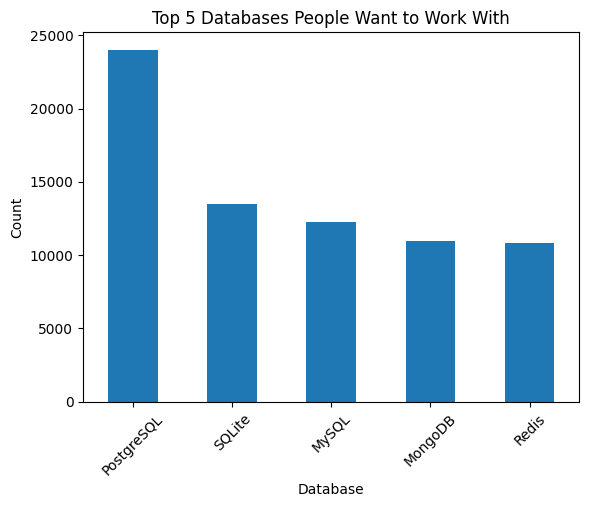

In [19]:
# Part 1: Get the data
QUERY = """
SELECT DatabaseWantToWorkWith FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
df5 = pd.read_sql_query(QUERY, conn)

# Part 2: Split the answers apart and count each database
all_databases = df5['DatabaseWantToWorkWith'].str.split(';').explode()
top5 = all_databases.value_counts().head(5)

# Part 3: Draw as a bar chart (histogram style)
top5.plot(kind='bar')
plt.title("Top 5 Databases People Want to Work With")
plt.xlabel("Database")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


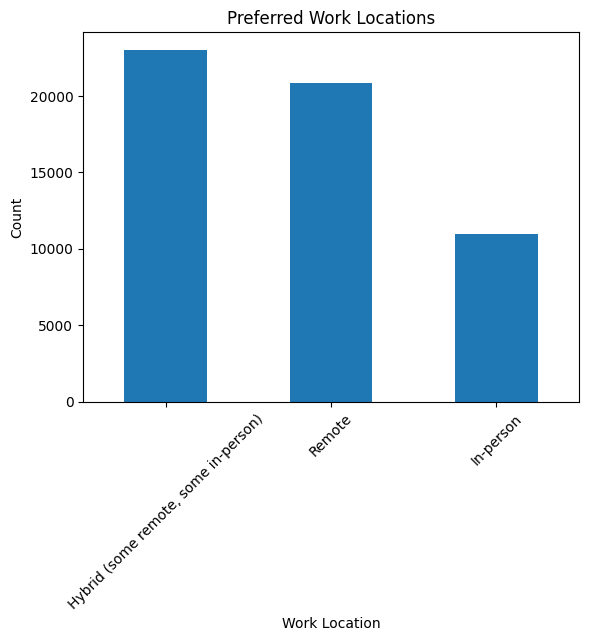

In [20]:
# Part 1: Get the data
QUERY = """
SELECT RemoteWork FROM main
WHERE RemoteWork IS NOT NULL
"""
df6 = pd.read_sql_query(QUERY, conn)

# Part 2: Count how many people picked each option
counts = df6['RemoteWork'].value_counts()

# Part 3: Draw the bar chart
counts.plot(kind='bar')
plt.title("Preferred Work Locations")
plt.xlabel("Work Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


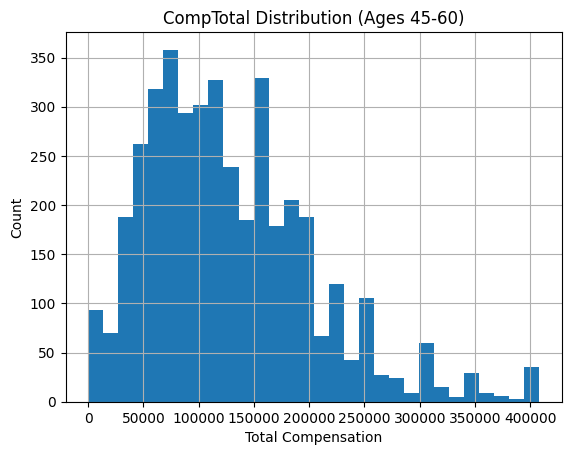

In [21]:
# Part 1: Get the data
QUERY = """
SELECT Age, CompTotal FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL
"""
df7 = pd.read_sql_query(QUERY, conn)

# Part 2: Turn Age words into numbers
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 25
}
df7['Age_numeric'] = df7['Age'].map(age_map)

# Part 3: Filter for ages 45 to 60
df7_filtered = df7[(df7['Age_numeric'] >= 45) & (df7['Age_numeric'] <= 60)]

# Part 4: Remove outliers so the chart isn't squished
Q1 = df7_filtered['CompTotal'].quantile(0.25)
Q3 = df7_filtered['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df7_filtered = df7_filtered[(df7_filtered['CompTotal'] >= lower) & (df7_filtered['CompTotal'] <= upper)]

# Part 5: Draw the histogram
df7_filtered['CompTotal'].hist(bins=30)
plt.title("CompTotal Distribution (Ages 45-60)")
plt.xlabel("Total Compensation")
plt.ylabel("Count")
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [22]:
# Part 1: Get the data
QUERY = """
SELECT JobSat, YearsCodePro FROM main
WHERE JobSat IS NOT NULL
AND YearsCodePro IS NOT NULL
"""
df8 = pd.read_sql_query(QUERY, conn)

# Part 2: Check what the data looks like
print(df8['JobSat'].head(10))
print("---")
print(df8['YearsCodePro'].head(10))

0     8.0
1     5.0
2    10.0
3     6.0
4     9.0
5     4.0
6     7.0
7     7.0
8     7.0
9     6.0
Name: JobSat, dtype: float64
---
0                  12
1                  27
2                  10
3    Less than 1 year
4                  18
5                  15
6                  17
7                   6
8                   7
9                  16
Name: YearsCodePro, dtype: object


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [23]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
